## Supply Chain Delay Prediction Project Guide

**Problem Statement**
  
Logistics and supply chain companies need to predict shipment delays to optimize operations and improve
customer satisfaction. The objective of this project is to predict the delay duration (in hours) using shipment,
route, warehouse, and external factors.


**Data Dictionary**

distance_km, shipment_weight, shipment_volume, traffic_index, route_complexity_score, number_of_stops,
driver_experience_years, origin_warehouse_load, destination_warehouse_load, processing_time_hours,
fuel_price, holiday_flag, strike_flag, dispatch_delay_hours, handling_issues_count, documentation_delay_flag,
delay_duration_hours (target)


**EDA Questions**

1. What is the distribution of delay_duration_hours?

2. How does distance_km affect delay?

3. Does traffic_index increase delay significantly?

4. How does route_complexity_score impact delay?

5. Do more stops increase delay?

6. Does driver experience reduce delay?

7. How does warehouse load affect delays?

8. Do holidays increase delays?

9. Do strikes cause extreme delays?

10. How does weather impact delay?

11. Which transport mode causes highest delay?

12. Is delay higher for long distance shipments?

13. Are there outliers in delay?

14. Which features are most correlated with delay?

15. Does dispatch delay directly affect final delay?

16. Are there nonlinear relationships present?

17. Do combinations of traffic + weather increase delay?

18. Does fuel price impact indirectly?

19. Which factor contributes most to delay?

20. What patterns can be observed overall?


**Feature Engineering**

Create new features such as: 

• delay_per_km

• load_ratio

• traffic_category

• risk_score

• weather_severity_index


**Feature Scaling**

Apply scaling for KNN and Polynomial Regression using StandardScaler or MinMaxScaler.


**Model Building**

Train: Linear Regression, Polynomial Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost,
KNN.


**Model Evaluation**

Use MAE, MSE, RMSE, and R² Score to compare models.

-----------------------------------------------------------

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Downloads/supply_chain_delay_dataset.csv");

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_category            10000 non-null  object 
 1   transport_mode              10000 non-null  object 
 2   weather_condition           10000 non-null  object 
 3   distance_km                 10000 non-null  float64
 4   shipment_weight             10000 non-null  float64
 5   shipment_volume             10000 non-null  float64
 6   traffic_index               10000 non-null  float64
 7   route_complexity_score      10000 non-null  float64
 8   number_of_stops             10000 non-null  int64  
 9   driver_experience_years     10000 non-null  float64
 10  origin_warehouse_load       10000 non-null  float64
 11  destination_warehouse_load  10000 non-null  float64
 12  processing_time_hours       10000 non-null  float64
 13  fuel_price                  1000

In [4]:
df.describe()

,distance_km,shipment_weight,shipment_volume,traffic_index,route_complexity_score,number_of_stops,driver_experience_years,origin_warehouse_load,destination_warehouse_load,processing_time_hours,fuel_price,holiday_flag,strike_flag,dispatch_delay_hours,handling_issues_count,documentation_delay_flag,delay_duration_hours
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1526.522569,251.119587,2.568797,5.550991,5.467110,4.538000,10.227778,0.902699,0.898996,24.451236,94.869113,0.14770,0.047200,12.103856,1.508400,0.100300,91.083836
std,849.725494,144.405285,1.408730,2.614869,2.611094,2.868271,5.595372,0.347071,0.346429,13.591480,14.427318,0.35482,0.212077,6.935224,1.227713,0.300415,19.645111
min,50.060000,1.050000,0.100000,1.000000,1.000000,0.000000,0.510000,0.300000,0.300000,1.010000,70.000000,0.00000,0.000000,0.000000,0.000000,0.000000,29.350000
25%,802.110000,126.317500,1.360000,3.300000,3.210000,2.000000,5.340000,0.600000,0.600000,12.557500,82.407500,0.00000,0.000000,6.040000,1.000000,0.000000,77.447500
50%,1535.040000,250.455000,2.570000,5.530000,5.425000,5.000000,10.240000,0.910000,0.900000,24.460000,94.715000,0.00000,0.000000,12.160000,1.000000,0.000000,90.735000
75%,2261.767500,376.975000,3.800000,7.860000,7.732500,7.000000,15.030000,1.200000,1.200000,36.290000,107.162500,0.00000,0.000000,18.102500,2.000000,0.000000,104.532500
max,2999.920000,499.900000,5.000000,10.000000,10.000000,9.000000,20.000000,1.500000,1.500000,47.990000,120.000000,1.00000,1.000000,24.000000,8.000000,1.000000,158.140000


In [5]:
df.dtypes

product_category               object
transport_mode                 object
weather_condition              object
distance_km                   float64
shipment_weight               float64
shipment_volume               float64
traffic_index                 float64
route_complexity_score        float64
number_of_stops                 int64
driver_experience_years       float64
origin_warehouse_load         float64
destination_warehouse_load    float64
processing_time_hours         float64
fuel_price                    float64
holiday_flag                    int64
strike_flag                     int64
dispatch_delay_hours          float64
handling_issues_count           int64
documentation_delay_flag        int64
delay_duration_hours          float64
dtype: object

**EDA Questions**
1. What is the distribution of delay_duration_hours?

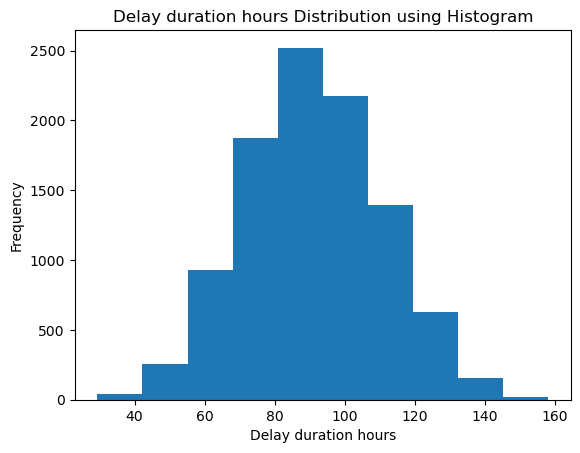

In [6]:
plt.hist(df["delay_duration_hours"])
plt.title("Delay duration hours Distribution using Histogram")
plt.xlabel("Delay duration hours")
plt.ylabel("Frequency")
plt.show()

2. How does distance_km affect delay?

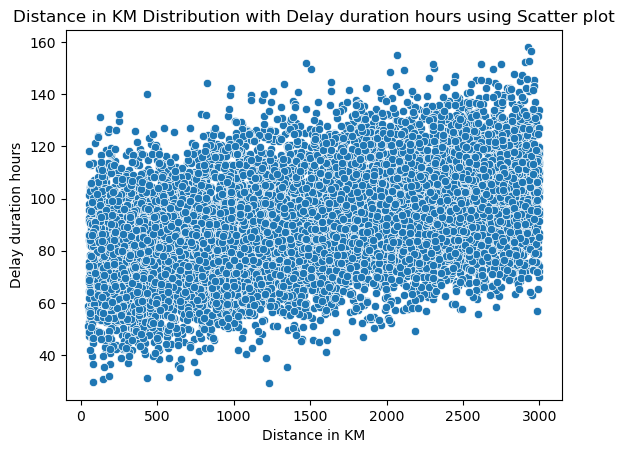

In [7]:
sns.scatterplot(x="distance_km", y="delay_duration_hours", data=df)
plt.title("Distance in KM Distribution with Delay duration hours using Scatter plot")
plt.xlabel("Distance in KM")
plt.ylabel("Delay duration hours")
plt.show()

3. Does traffic_index increase delay significantly?

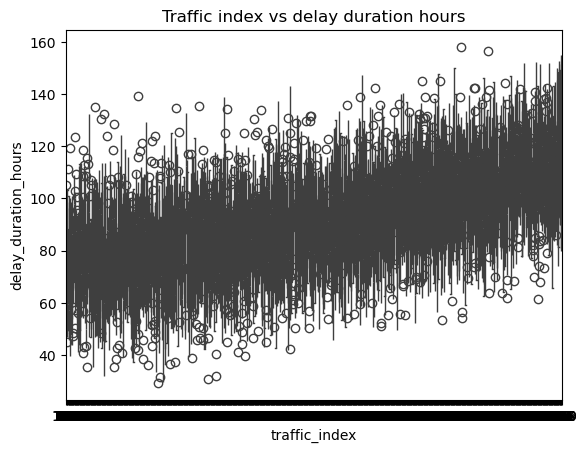

In [8]:
sns.boxplot(x='traffic_index', y='delay_duration_hours', data=df)
plt.title("Traffic index vs delay duration hours")
plt.show()

4. How does route_complexity_score impact delay?

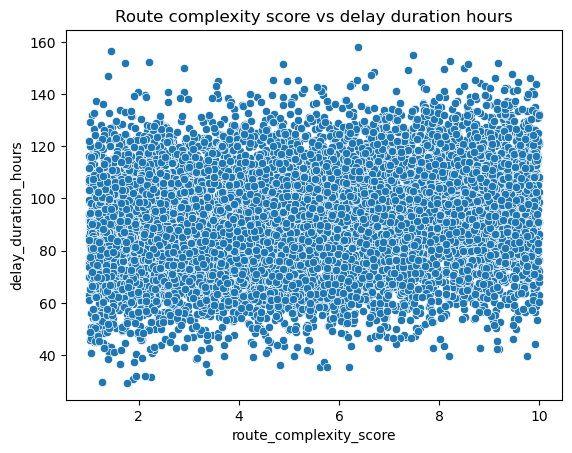

In [9]:
sns.scatterplot(x='route_complexity_score', y='delay_duration_hours', data=df)
plt.title("Route complexity score vs delay duration hours")
plt.show()

5. Do more stops increase delay?

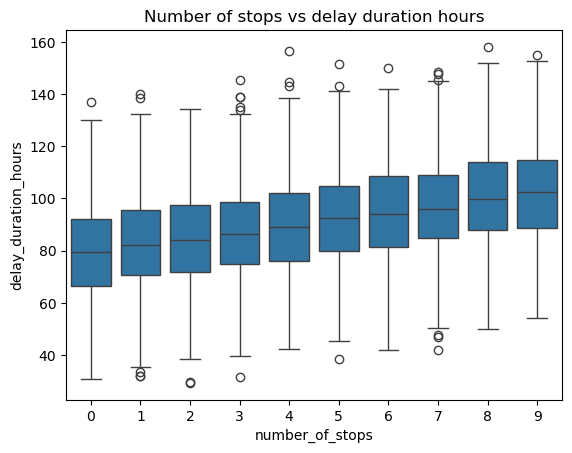

In [10]:
sns.boxplot(x='number_of_stops', y='delay_duration_hours', data=df)
plt.title("Number of stops vs delay duration hours")
plt.show()

6. Does driver experience reduce delay?

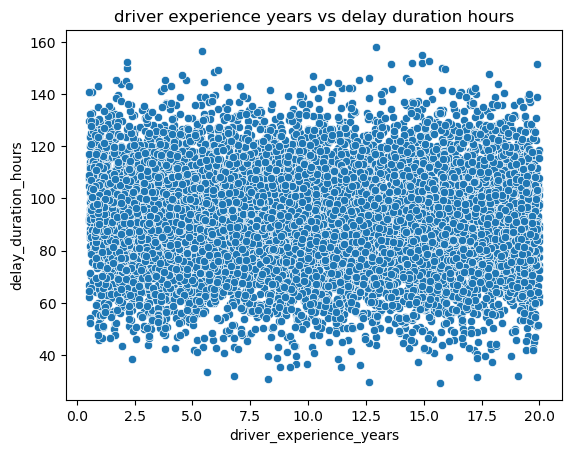

In [11]:
sns.scatterplot(x='driver_experience_years', y='delay_duration_hours', data=df)
plt.title("driver experience years vs delay duration hours")
plt.show()

7. How does warehouse load affect delays?

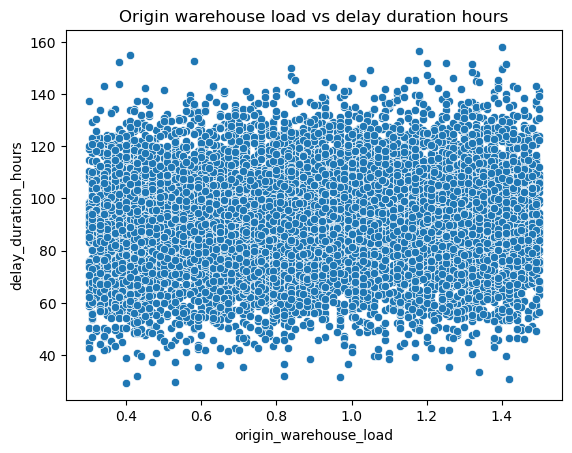

In [12]:
sns.scatterplot(x='origin_warehouse_load', y='delay_duration_hours', data=df)
plt.title("Origin warehouse load vs delay duration hours")
plt.show()

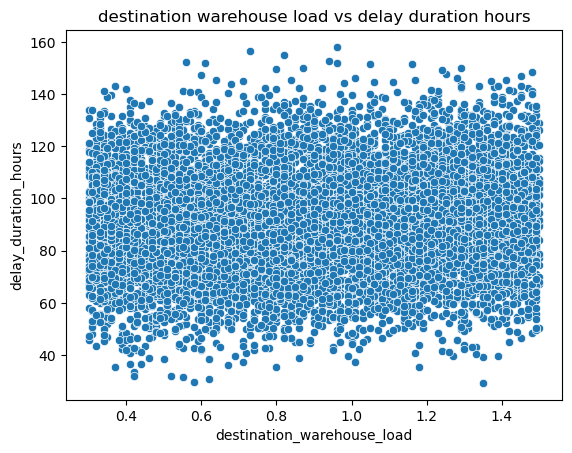

In [13]:
sns.scatterplot(x='destination_warehouse_load', y='delay_duration_hours', data=df)
plt.title("destination warehouse load vs delay duration hours")
plt.show()

8. Do holidays increase delays?

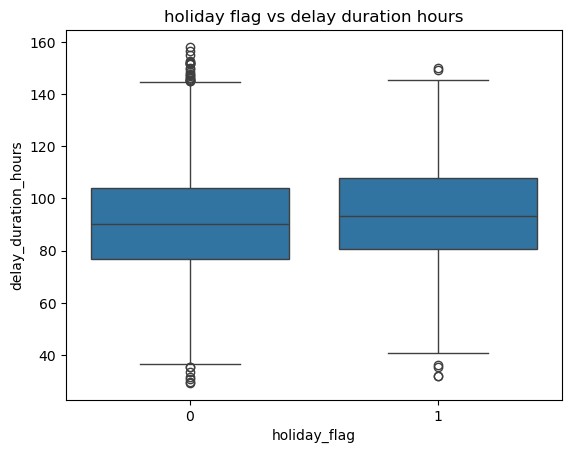

In [14]:
sns.boxplot(x='holiday_flag', y='delay_duration_hours', data=df)
plt.title("holiday flag vs delay duration hours")
plt.show()

9. Do strikes cause extreme delays?

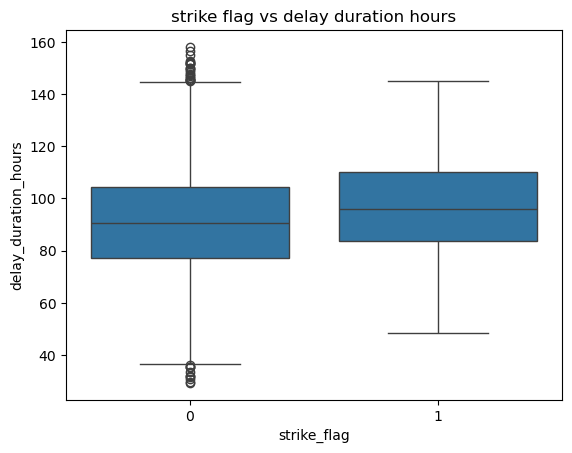

In [15]:
sns.boxplot(x='strike_flag', y='delay_duration_hours', data=df)
plt.title("strike flag vs delay duration hours")
plt.show()

10. How does weather impact delay

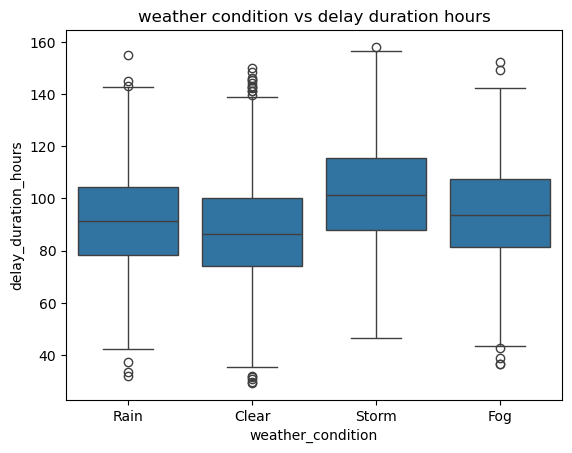

In [16]:
sns.boxplot(x='weather_condition', y='delay_duration_hours', data=df)
plt.title('weather condition vs delay duration hours')
plt.show()

11. Which transport mode causes highest delay?

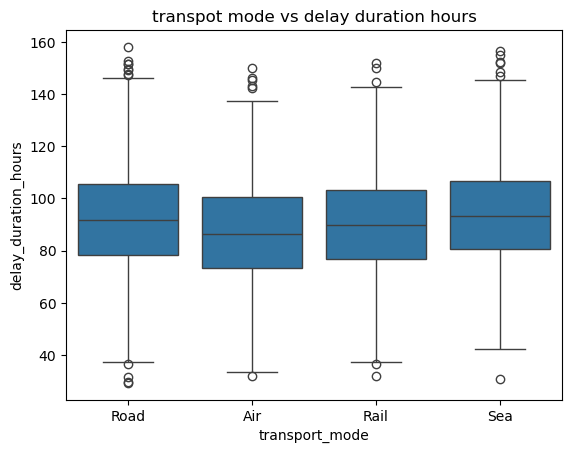

In [17]:
sns.boxplot(x='transport_mode', y='delay_duration_hours', data=df)
plt.title('transpot mode vs delay duration hours')
plt.show()

12. Is delay higher for long distance shipments?

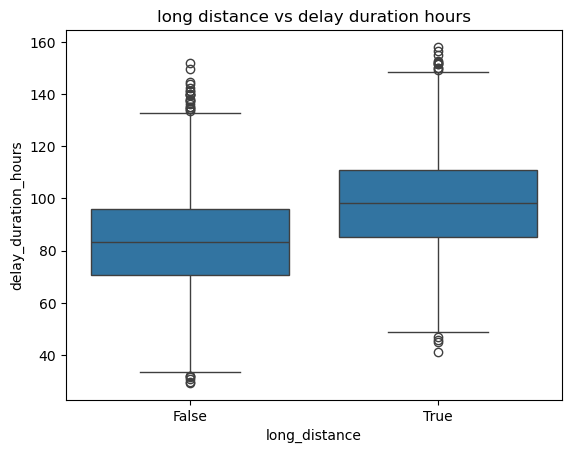

In [18]:
df['long_distance'] = df['distance_km'] > df['distance_km'].median()
sns.boxplot(x='long_distance', y='delay_duration_hours', data=df)
plt.title('long distance vs delay duration hours')
plt.show()

13. Are there outliers in delay?

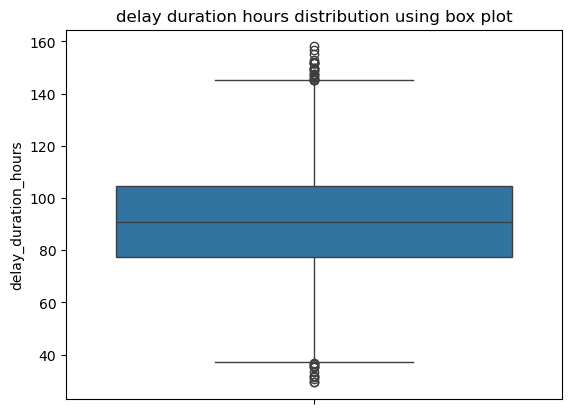

In [19]:
sns.boxplot(df['delay_duration_hours'])
plt.title('delay duration hours distribution using box plot')
plt.show()

14. Which features are most correlated with delay?

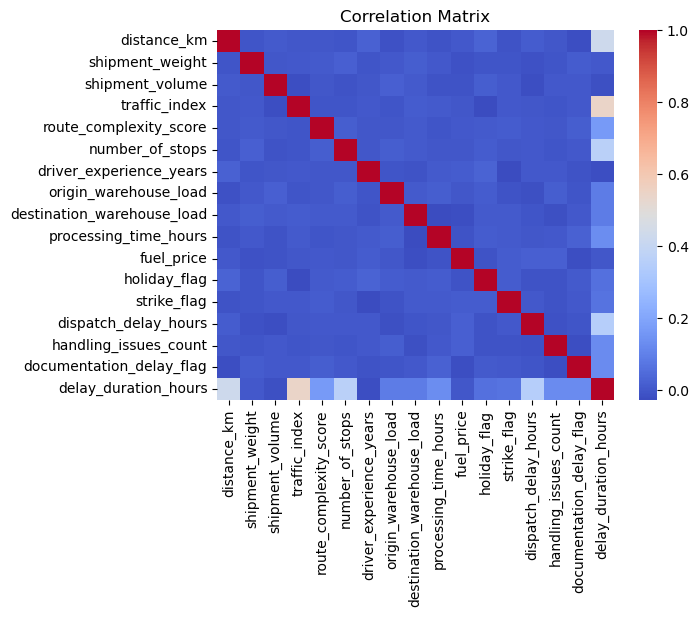

In [20]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

15. Does dispatch delay directly affect final delay?

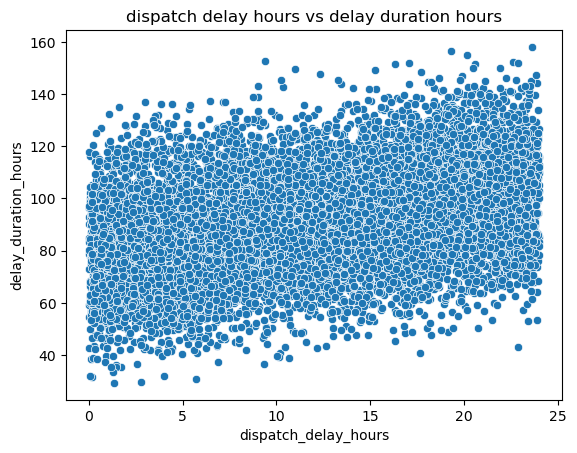

In [21]:
sns.scatterplot(x='dispatch_delay_hours', y='delay_duration_hours', data=df)
plt.title('dispatch delay hours vs delay duration hours')
plt.show()

16. Are there nonlinear relationships present?

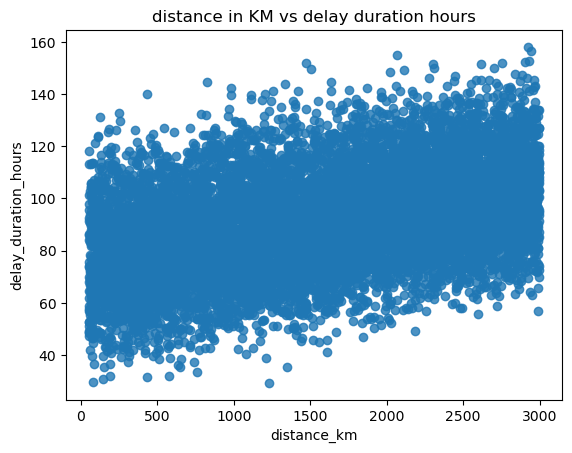

In [22]:
sns.regplot(x='distance_km', y='delay_duration_hours', data=df)
plt.title('distance in KM vs delay duration hours')
plt.show()

17. Do combinations of traffic + weather increase delay?

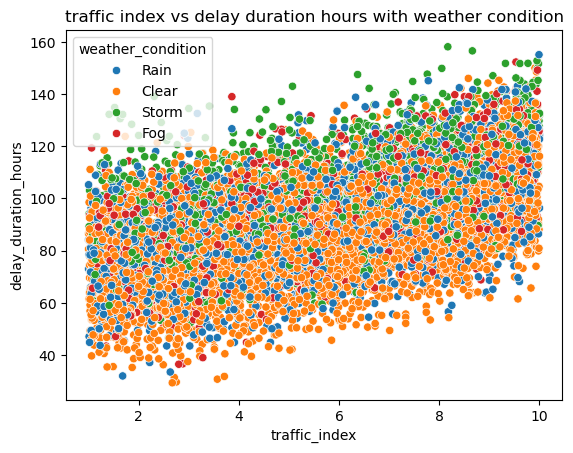

In [23]:
sns.scatterplot(x='traffic_index', y='delay_duration_hours',hue='weather_condition', data=df)
plt.title('traffic index vs delay duration hours with weather condition')
plt.show()

18. Does fuel price impact indirectly

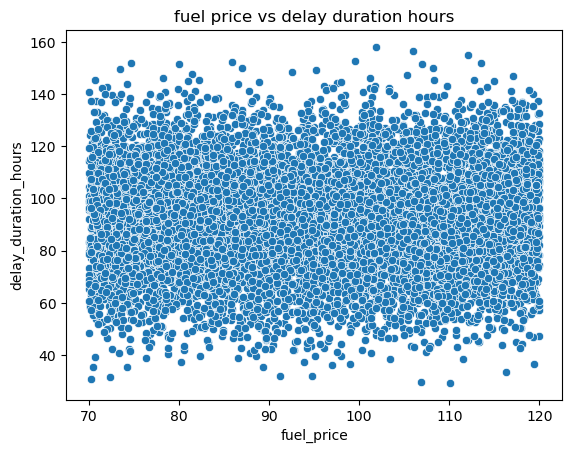

In [24]:
sns.scatterplot(x='fuel_price', y='delay_duration_hours', data=df)
plt.title('fuel price vs delay duration hours')
plt.show()

19. Which factor contributes most to delay?

In [25]:
corr = df.corr(numeric_only=True)
corr['delay_duration_hours'].sort_values(ascending=False)

delay_duration_hours          1.000000
traffic_index                 0.543387
distance_km                   0.429747
long_distance                 0.376844
number_of_stops               0.365419
dispatch_delay_hours          0.353908
route_complexity_score        0.167224
processing_time_hours         0.133715
handling_issues_count         0.129305
documentation_delay_flag      0.126197
destination_warehouse_load    0.089316
origin_warehouse_load         0.088724
strike_flag                   0.067180
holiday_flag                  0.059003
shipment_weight               0.004508
fuel_price                   -0.000199
shipment_volume              -0.014787
driver_experience_years      -0.020945
Name: delay_duration_hours, dtype: float64

20. What patterns can be observed overall?

In this data frame we get to know that 
- Due to traffic, distance and stops may increase the delays
- Driver experience reduces delays
- Most of the delay happens due to sadden changes in climate like storm, rain and fog
- Sometime in holidays it might be reason of delaying
- Most of the dealy occur in transport mode is road and sea
- There is some outliers in dealy feature
- The strong correction of delay with traffic index,distance and number of stops
- In case of dispatch delay is increasing then delay duration also increases
- When both weather and traffic are changed or increase then it might increase delay duration
- There is nothing related to fuel price with delay duration


--------------------


**Feature Engineering**

Create new features such as:

• delay_per_km

• load_ratio

• traffic_category

• risk_score

• weather_severity_index

In [27]:
df['delay_per_km']=df['delay_duration_hours']/(df['distance_km']+1)
df['delay_per_km']

0       0.442887
1       0.044136
2       0.044681
3       0.049047
4       0.067726
          ...   
9995    0.047100
9996    0.075444
9997    0.042339
9998    0.449578
9999    0.067780
Name: delay_per_km, Length: 10000, dtype: float64

In [28]:
df['load_ratio']=df['origin_warehouse_load']/(df['destination_warehouse_load']+1)
df['load_ratio']

0       0.206897
1       0.222826
2       0.400000
3       0.283654
4       0.212963
          ...   
9995    0.771739
9996    0.543478
9997    0.352564
9998    0.525641
9999    0.476190
Name: load_ratio, Length: 10000, dtype: float64

In [29]:
df['traffic_category']=pd.cut(
    df['traffic_index'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

df = pd.get_dummies(df, columns=['traffic_category'], drop_first=True)

In [30]:
df.columns

Index(['product_category', 'transport_mode', 'weather_condition',
       'distance_km', 'shipment_weight', 'shipment_volume', 'traffic_index',
       'route_complexity_score', 'number_of_stops', 'driver_experience_years',
       'origin_warehouse_load', 'destination_warehouse_load',
       'processing_time_hours', 'fuel_price', 'holiday_flag', 'strike_flag',
       'dispatch_delay_hours', 'handling_issues_count',
       'documentation_delay_flag', 'delay_duration_hours', 'long_distance',
       'delay_per_km', 'load_ratio', 'traffic_category_Medium',
       'traffic_category_High'],
      dtype='object')

In [31]:
df['traffic_category_Medium']

0        True
1       False
2       False
3        True
4       False
        ...  
9995    False
9996    False
9997     True
9998    False
9999    False
Name: traffic_category_Medium, Length: 10000, dtype: bool

In [32]:
df['traffic_category_High']

0       False
1        True
2        True
3       False
4        True
        ...  
9995     True
9996     True
9997    False
9998     True
9999    False
Name: traffic_category_High, Length: 10000, dtype: bool

In [33]:
df['risk_score'] = (df['traffic_index']+df['route_complexity_score']+df['number_of_stops'] +df['handling_issues_count'])

In [34]:
df['risk_score']

0       21.57
1       17.37
2       20.91
3       11.10
4       17.75
        ...  
9995    18.03
9996    26.39
9997    18.26
9998    15.30
9999    13.20
Name: risk_score, Length: 10000, dtype: float64

In [35]:
weather_map = {
    'Clear': 1,
    'Cloudy': 2,
    'Rain': 3,
    'Storm': 4,
    'Fog': 3
}

In [37]:
df = pd.get_dummies(df, columns=['product_category','transport_mode'], drop_first=True)
df['weather_severity_index'] = df['weather_condition'].map(weather_map)
df.drop('weather_condition', axis=1, inplace=True)

In [38]:
df.columns

Index(['distance_km', 'shipment_weight', 'shipment_volume', 'traffic_index',
       'route_complexity_score', 'number_of_stops', 'driver_experience_years',
       'origin_warehouse_load', 'destination_warehouse_load',
       'processing_time_hours', 'fuel_price', 'holiday_flag', 'strike_flag',
       'dispatch_delay_hours', 'handling_issues_count',
       'documentation_delay_flag', 'delay_duration_hours', 'long_distance',
       'delay_per_km', 'load_ratio', 'traffic_category_Medium',
       'traffic_category_High', 'risk_score', 'product_category_Clothing',
       'product_category_Electronics', 'product_category_Food',
       'product_category_Furniture', 'product_category_Pharma',
       'transport_mode_Rail', 'transport_mode_Road', 'transport_mode_Sea',
       'weather_severity_index'],
      dtype='object')

In [39]:
df['weather_severity_index']

0       3
1       3
2       3
3       1
4       3
       ..
9995    1
9996    3
9997    3
9998    1
9999    3
Name: weather_severity_index, Length: 10000, dtype: int64

----------------

**Feature Scaling**
  
Apply scaling for KNN and Polynomial Regression using StandardScaler or MinMaxScaler.

In [54]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score, classification_report 

In [43]:
X = df.drop('delay_duration_hours', axis=1)
y = df['delay_duration_hours']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [47]:
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
y_pred_knn=knn.predict(X_test_scaled)

In [56]:
print(y_pred_knn)

[ 89.294 110.674 110.02  ...  89.212  91.44  107.072]


In [49]:
poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train_scaled)
X_test_poly=poly.transform(X_test_scaled)
model=LinearRegression()
model.fit(X_train_poly,y_train)
y_pred_poly=model.predict(X_test_poly)

In [51]:
print(y_pred_poly)

[ 90.75 107.1  119.41 ...  91.67  97.82  95.81]


----------------

**Model Building**

Train: Linear Regression, Polynomial Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost,
KNN.

In [59]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr=lr.predict(X_test)

In [60]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
pr = LinearRegression()
pr.fit(X_train_poly, y_train)
y_pred_pr = pr.predict(X_test_poly)

In [61]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [62]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [63]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [64]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [65]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

**Model Evaluation**

Use MAE, MSE, RMSE, and R² Score to compare models.

In [66]:
def evaluate(y_test, y_pred, name):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [67]:
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_pr, "Polynomial Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")
evaluate(y_test, y_pred_xgb, "XGBoost")
evaluate(y_test, y_pred_knn, "KNN")


Linear Regression
MAE: 4.490764243226833
RMSE: 5.603497347867813
R2 Score: 0.923906103464983

Polynomial Regression
MAE: 5.41227507255826e-13
RMSE: 7.019591182873534e-13
R2 Score: 1.0

Decision Tree
MAE: 6.351554651099955
RMSE: 8.799188911768079
R2 Score: 0.8123637409810529

Random Forest
MAE: 3.8250711500000008
RMSE: 5.412768034996973
R2 Score: 0.9289980439138712

Gradient Boosting
MAE: 4.584881663856555
RMSE: 5.7806469264596245
R2 Score: 0.9190187697234597

XGBoost
MAE: 3.292272856063843
RMSE: 4.3274337524113315
R2 Score: 0.9546170901621792

KNN
MAE: 8.888122
RMSE: 11.101345608348566
R2 Score: 0.7013361020797741


We trained Multiple regression models including Linear, Polynomial, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and KNN were trained and evaluated.Some models like Random forest and XGBoost performed best to capture complex nonlinear relationships.